# MMC Chatbot — MEAL Feedback EDA

Exploratory data analysis of `Base de datos MEAL Sami_060526.xlsx` (~24 post-interaction feedback records).

**What is this?** *Sami* is a WhatsApp chatbot that supports migrants in Colombia. After each interaction, users are invited to give feedback. *MEAL* stands for **Monitoring, Evaluation, Accountability and Learning** — the humanitarian-sector practice of systematically collecting feedback to check whether a service is actually helping the people it's meant to serve. This notebook turns that raw feedback into a picture of how Sami is doing.

**The story this notebook tells.** We follow the feedback from raw data to insight:

1. **How much feedback do we have, and can we trust it?** (Sections 1–2) — volume, completeness, and how representative it is.
2. **Are users satisfied, and would they recommend Sami?** (Sections 3–4) — the core satisfaction signals.
3. **How did they find Sami, and what do they say in their own words?** (Sections 5–6) — reach and qualitative themes.
4. **Is the service improving as it matures?** (Section 7) — trends over time.

---

### How to read this notebook

Every section opens with a plain-language summary — **What this shows** and **Why it matters** — that needs no technical background. Where a chart or calculation involves a non-obvious choice (a scale, a smoothing window, a data-cleaning rule), a short **Technical note** explains it for readers who want the detail. You can follow the narrative top-to-bottom without reading any code.

> **Technical note — the dataset is small (n ≈ 24).** Every chart here should be read as *directional*, not statistically conclusive. A handful of responses can move a percentage substantially, so we favour showing raw counts alongside percentages and avoid over-interpreting small differences.

In [12]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from collections import Counter
from wordcloud import WordCloud
from palette import (
    AGUA, MADERA, HONGO, NEGRO,
    CIELO, AMEBA, ARBOL,
    AGUA_LIGHT, AGUA_MID,
)

# Shared plot styling so every chart matches the Diversa brand look
plt.rcParams.update({
    'figure.facecolor': CIELO,
    'axes.facecolor': CIELO,
    'axes.edgecolor': NEGRO,
    'text.color': NEGRO,
    'axes.labelcolor': NEGRO,
    'xtick.color': NEGRO,
    'ytick.color': NEGRO,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color cycle used to give each bar in a categorical bar chart its own brand color
BAR_PALETTE = [AGUA, MADERA, AMEBA, ARBOL, HONGO, AGUA_MID]

## 1. Data Load

**What this shows:** The two source spreadsheets we work with, and the cleaning we apply before any analysis. The **MEAL feedback form** (~24 post-interaction survey responses) is the focus of this notebook; the **responses database** (~240 chatbot interaction records) is loaded only to put the feedback in context (e.g. what share of users actually responded).

**Why it matters:** Raw survey exports are messy — banner rows, blank lines, and long Spanish question text as column names. Getting to a clean table first means every chart downstream is built on the same trustworthy foundation.

> **Technical note.** The sheet has two banner rows above the real headers, so we read with `header=2` and drop fully-blank rows. Columns are renamed to short, code-friendly labels. The Spanish Likert ratings are mapped to a **1–5 numeric scale** (`Nada útil`=1 … `Muy útil`=5) in `rating_num` — this is what lets us average the score and plot its trend over time in Section 7.

In [13]:
# Source spreadsheets: MEAL feedback form and chatbot interaction log
MEAL_PATH = '../data_&_docs/Base de datos MEAL Sami_060526.xlsx'
RESP_PATH = '../data_&_docs/Base de datos respuestas Sami_060526.xlsx'

# header=2: the sheet has two banner rows above the real column headers
meal = pd.read_excel(MEAL_PATH, sheet_name='mmc-meal', header=2)
meal = meal.dropna(how='all').reset_index(drop=True)  # drop blank rows left by the banner

# Replace the long Spanish question text with short, code-friendly column names
meal.columns = [
    'Name', 'Timestamp',
    'usefulness_rating', 'would_recommend',
    'recommendation_text', 'discovery_channel', 'discovery_other',
]

meal['Timestamp'] = pd.to_datetime(meal['Timestamp'], errors='coerce')

# Map the Spanish Likert labels to a 1-5 numeric scale so we can average and plot trends
RATING_MAP = {
    'Muy útil': 5, 'Útil': 4,
    'Medianamente útil': 3, 'Poco útil': 2, 'Nada útil': 1,
}
meal['rating_num'] = meal['usefulness_rating'].map(RATING_MAP)

print(f"MEAL records: {len(meal)}")
meal.head()


MEAL records: 24


,Name,Timestamp,usefulness_rating,would_recommend,recommendation_text,discovery_channel,discovery_other,rating_num
0,whatsapp:+56929572884,2026-03-26 00:47:35.583000+00:00,Muy útil,Sí,Excelente,Recomendación de una ONG,NaN,5
1,whatsapp:+573113165608,2026-03-26 10:12:14.030000+00:00,Nada útil,Prefiero no responder,"Ayuda, no se cómo activar mi línea nueva Tigo ...",Otro,Redes sociales,1
2,whatsapp:+16462943119,2026-03-26 16:06:16.380000+00:00,Nada útil,Prefiero no responder,No recibí ninguna información.,Redes sociales,NaN,1
3,whatsapp:+573192311911,2026-03-27 03:36:50.975000+00:00,Medianamente útil,Prefiero no responder,No,Recomendación de una ONG,NaN,3
4,whatsapp:+16462943119,2026-03-27 11:47:53.350000+00:00,Nada útil,Prefiero no responder,No recibí información,Otro,Otro,1


## 2. Data Quality

**What this shows:** How complete the feedback data is (which fields have gaps), and what share of all chatbot users actually filled out the feedback form — the **MEAL response rate**.

**Why it matters:** Two reliability checks before we draw any conclusions. First, gaps matter because charts silently drop empty rows — knowing where the gaps are tells us which questions to read with caution. Second, the response rate tells us how *representative* the feedback is: if only a small fraction of users respond, satisfaction scores reflect that vocal minority, not necessarily everyone.

> **Technical note.** The missing-values bar (`missingno`) shows the non-null count per column. The response rate is computed as unique MEAL respondents ÷ unique users in the full responses database. Because both numbers are small, treat the rate as a rough order of magnitude, not a precise figure.

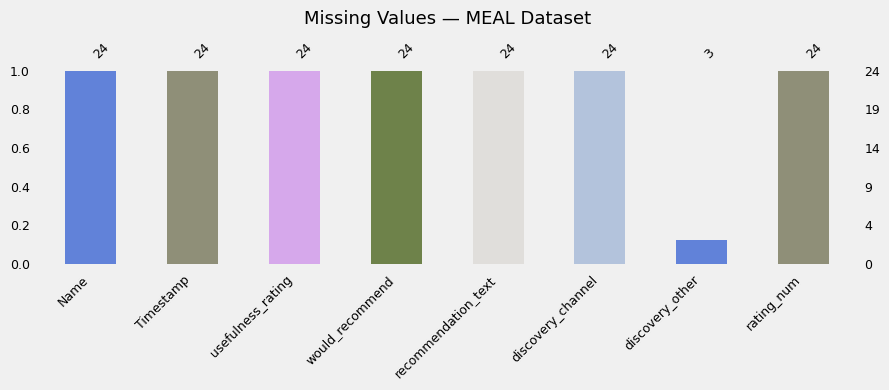

Total chatbot users (responses DB): 233
MEAL respondents:                   22
MEAL response rate:                 9.4%


In [14]:
# Each MEAL column gets its own brand color; bar height/label = non-null count
fig, ax = plt.subplots(figsize=(9, 4))
quality_colors = [BAR_PALETTE[i % len(BAR_PALETTE)] for i in range(len(meal.columns))]
msno.bar(meal, ax=ax, color=quality_colors, fontsize=9)
ax.set_title('Missing Values — MEAL Dataset', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# Load the full interaction log to compute how many chatbot users left MEAL feedback
resp_df = pd.read_excel(RESP_PATH, sheet_name='mmc bot - responses', header=2)
resp_df = resp_df.dropna(how='all').reset_index(drop=True)
resp_df['Messages'] = pd.to_numeric(resp_df['Messages'], errors='coerce')
resp_df['Questions per user'] = pd.to_numeric(resp_df['Questions per user'], errors='coerce')

total_users = resp_df['Name'].nunique()
meal_users  = meal['Name'].nunique()
print(f"Total chatbot users (responses DB): {total_users}")
print(f"MEAL respondents:                   {meal_users}")
print(f"MEAL response rate:                 {meal_users / total_users * 100:.1f}%")


## 3. Usefulness Rating

**What this shows:** The headline satisfaction number. Users rated how useful Sami was on a 5-point scale from *Nada útil* (not useful at all) to *Muy útil* (very useful). The bar chart shows how many people chose each level, and the average score is printed on the chart.

**Why it matters:** This is the single most direct measure of whether Sami is helping. The shape of the distribution matters as much as the average — satisfaction clustered at the top is a very different story from opinions split between "very useful" and "not useful at all," even if the two produce a similar mean.

> **Technical note.** Bars are ordered low→high (not by frequency) and shaded with a light-to-dark colour ramp so the eye reads the rating scale, not just the counts. The mean is computed from the 1–5 `rating_num` mapping defined in Section 1 and annotated directly on the axes for an at-a-glance read.

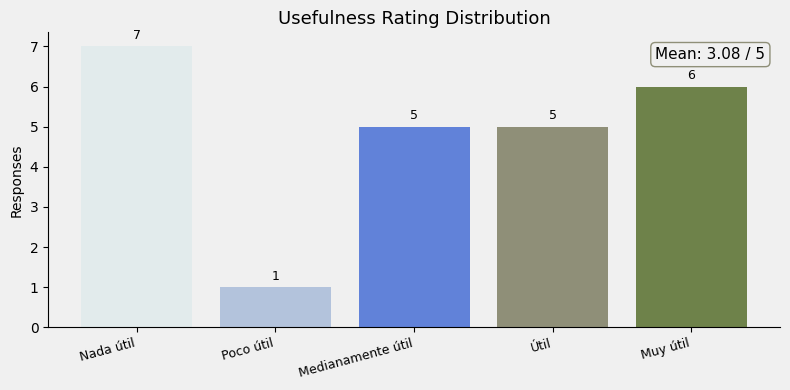

In [15]:
# Order categories from least to most useful (instead of by frequency)
rating_order = ['Nada útil', 'Poco útil', 'Medianamente útil', 'Útil', 'Muy útil']
rating_counts = meal['usefulness_rating'].value_counts()
rating_counts = rating_counts.reindex(
    [r for r in rating_order if r in rating_counts.index], fill_value=0
)

# Light-to-dark ramp visually encodes the low-to-high rating scale
ramp = [AGUA_LIGHT, AGUA_MID, AGUA, MADERA, ARBOL][:len(rating_counts)]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(rating_counts)), rating_counts.values, color=ramp)
ax.set_xticks(range(len(rating_counts)))
ax.set_xticklabels(rating_counts.index, rotation=15, ha='right', fontsize=9)
ax.bar_label(bars, padding=3, fontsize=9)  # exact count above each bar
ax.set_ylabel('Responses')
ax.set_title('Usefulness Rating Distribution', fontsize=13)

# Annotate the mean rating directly on the chart instead of a separate gauge
mean_r = meal['rating_num'].mean()
ax.text(0.98, 0.95, f'Mean: {mean_r:.2f} / 5', transform=ax.transAxes,
        ha='right', va='top', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=CIELO, edgecolor=MADERA))

ax.set_facecolor(CIELO)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()


## 4. Would Recommend

**What this shows:** Whether users would recommend Sami to someone else in a similar situation, split into *Sí* (yes), *No*, and *Prefiero no responder* (prefer not to answer).

**Why it matters:** This is a word-of-mouth signal, and it complements the usefulness rating rather than repeating it — someone can find a tool moderately useful but still not recommend it, or vice versa. For a service that reaches migrant communities largely through trust networks, a high "Sí" share points to real potential for organic growth.

> **Technical note.** This is an NPS-style proxy, not a true Net Promoter Score (there's no 0–10 scale). Each answer is given a meaningful, fixed colour (green-ish *Sí*, brown *No*, neutral for *Prefiero no responder*) rather than an arbitrary palette cycle, so the chart's colours carry consistent meaning. Exact counts are printed beneath the percentages, since with ~24 responses a percentage alone can be misleading.

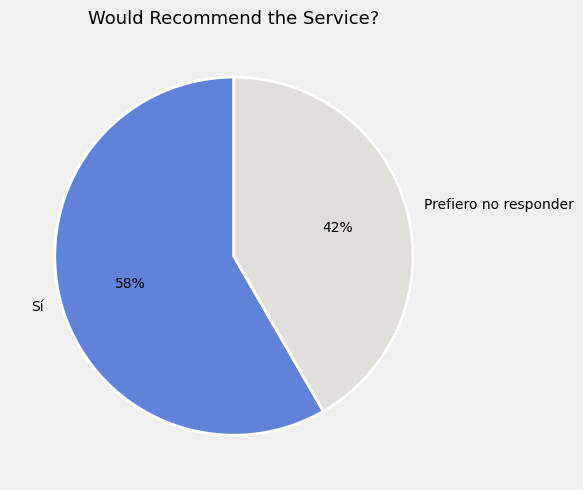

would_recommend
Sí                       14
Prefiero no responder    10


In [16]:
# Map each recommendation answer to a meaningful brand color (not an arbitrary cycle)
rec = meal['would_recommend'].value_counts()
color_map = {'Sí': AGUA, 'No': MADERA, 'Prefiero no responder': HONGO}
colors = [color_map.get(v, AMEBA) for v in rec.index]

fig, ax = plt.subplots(figsize=(6, 5))
_, texts, autotexts = ax.pie(
    rec.values, labels=rec.index, autopct='%1.0f%%',
    colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title('Would Recommend the Service?', fontsize=13)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()

# Print exact counts behind the percentages shown in the pie chart
print(rec.to_string())


## 5. Discovery Channel

**What this shows:** How users first heard about Sami — for example through a partner NGO, social media, or word of mouth.

**Why it matters:** Discovery channels tell outreach teams where their effort is actually paying off. There's also a risk angle: if nearly everyone arrives through a single channel (say, one partner organization), the service is dependent on that one relationship. A more even spread signals broader, more resilient reach.

> **Technical note.** Each channel gets its own brand colour so bars are individually distinguishable, and exact counts are labelled on each bar. The "Otro" (Other) free-text answers are captured in a separate `discovery_other` column; this chart shows the structured channel choice.

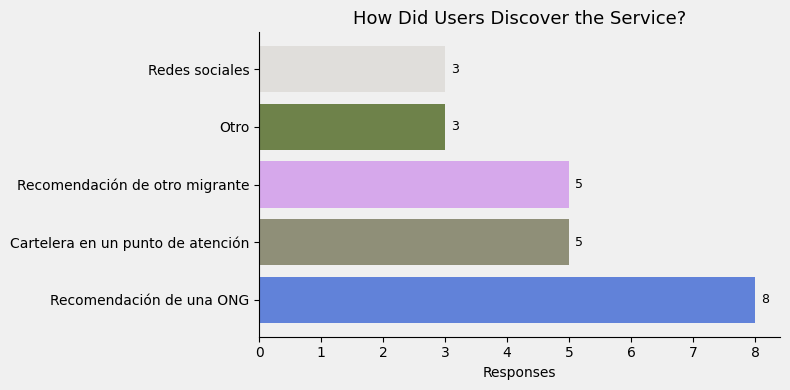

In [17]:
# One brand color per channel makes each bar individually distinguishable
disc = meal['discovery_channel'].value_counts()
colors = [BAR_PALETTE[i % len(BAR_PALETTE)] for i in range(len(disc))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(disc.index, disc.values, color=colors)
ax.bar_label(ax.containers[0], padding=4, fontsize=9)  # exact count per channel
ax.set_xlabel('Responses')
ax.set_title('How Did Users Discover the Service?', fontsize=13)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()

## 6. Open Text — What Users Recommend

**What this shows:** Users' own words. The feedback form asks what they would recommend improving about Sami. We look at this two ways: a **length distribution** (how much people wrote) and a **word cloud** (which words come up most often).

**Why it matters:** Numbers tell us *whether* people are satisfied; the open text starts to tell us *why*, and surfaces concrete improvement ideas. How much someone writes is itself a rough signal of engagement — a one-word reply and a detailed paragraph reflect very different levels of investment. The word cloud lets us spot recurring themes across all responses at a glance, without reading each one individually.

> **Technical note.** Length is measured in characters as an engagement proxy, with the mean marked. For the word cloud, text is lower-cased, stripped of punctuation, and filtered against a Spanish stop-word list (common words like *de, la, que*) plus a minimum length, so only meaningful terms remain. With so few responses, the word cloud is a qualitative prompt for closer reading — not a quantitative ranking.

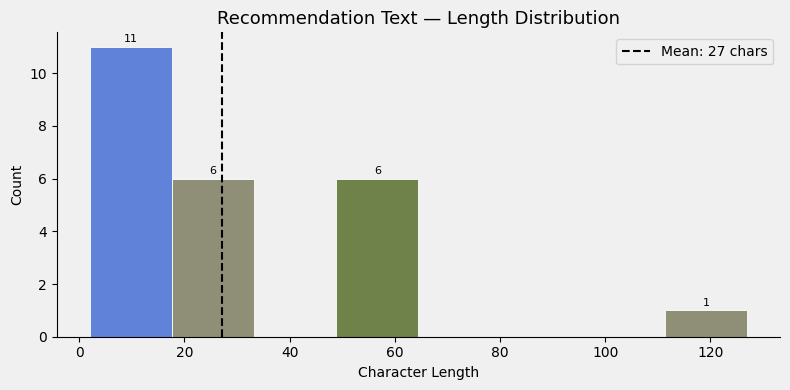

In [18]:
# Character length of each free-text recommendation, as a proxy for engagement depth
rec_text = meal['recommendation_text'].dropna()
lengths = rec_text.str.len()

fig, ax = plt.subplots(figsize=(8, 4))
counts, bins, patches = ax.hist(lengths, bins=8, edgecolor='white', linewidth=0.6)

# Color each bin from the brand palette and label it with its exact count
for i, patch in enumerate(patches):
    patch.set_facecolor(BAR_PALETTE[i % len(BAR_PALETTE)])
ax.bar_label(patches, labels=[f'{int(c)}' if c > 0 else '' for c in counts], padding=2, fontsize=8)

# NEGRO keeps the mean line visible against the multi-colored bars
ax.axvline(lengths.mean(), color=NEGRO, linestyle='--',
           label=f'Mean: {lengths.mean():.0f} chars')
ax.legend()
ax.set_xlabel('Character Length')
ax.set_ylabel('Count')
ax.set_title('Recommendation Text — Length Distribution', fontsize=13)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()


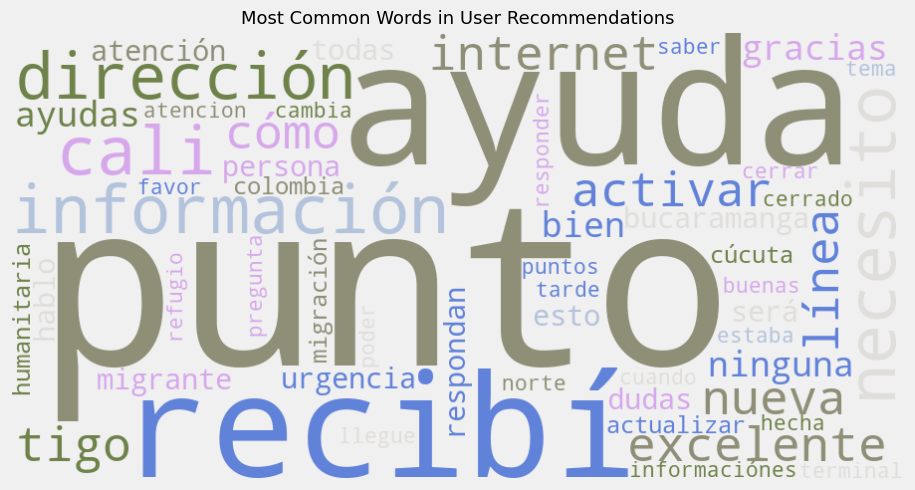

In [19]:
# Common Spanish stopwords to exclude so the word cloud highlights meaningful themes
ES_STOPWORDS = {
    'de', 'la', 'el', 'en', 'y', 'a', 'que', 'no', 'es', 'se', 'los', 'las',
    'con', 'por', 'un', 'una', 'para', 'más', 'del', 'al', 'lo', 'le', 'su',
    'me', 'mi', 'como', 'muy', 'pero', 'si', 'ya', 'este', 'esta', 'son', 'hay',
    'fue', 'ser', 'tiene', 'han', 'he', 'nos', 'sus', 'todo', 'también',
}

# Tokenize, strip punctuation, and drop short words / stopwords
rec_text = meal['recommendation_text'].dropna()
all_words = ' '.join(rec_text.str.lower()).split()
words = [w.strip('.,;:!?()"\'') for w in all_words
         if len(w) > 3 and w.strip('.,;:!?()"\'') not in ES_STOPWORDS]
word_freq = Counter(words)

# Cycle through the brand palette so word colors match the rest of the notebook
def _brand_color_func(word, font_size, position, orientation, random_state, **kwargs):
    return BAR_PALETTE[random_state.randint(0, len(BAR_PALETTE) - 1)]

wc = WordCloud(
    width=900, height=450, background_color=CIELO,
    color_func=_brand_color_func, prefer_horizontal=0.9,
).generate_from_frequencies(word_freq)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Words in User Recommendations', fontsize=13)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()

## 7. MEAL Responses Over Time

**What this shows:** The feedback as a timeline instead of a snapshot. The left panel tracks the **running total of responses** since launch; the right panel plots **each usefulness rating on the day it was given**, with a smoothed trend line through them.

**Why it matters:** A single average hides whether things are getting better or worse. This is where we can see momentum: a steadily climbing total means the feedback loop is alive and people keep responding, while a rising (or falling) trend line shows whether users are growing more — or less — satisfied as Sami evolves.

> **Technical note.** The left panel is a daily count accumulated into a cumulative sum. The right panel's trend line is a **14-day rolling mean** (`min_periods=2`): each point averages the ratings from the surrounding two weeks, which smooths out day-to-day noise so a genuine direction is visible despite the sparse data. With ~24 points spread over weeks, read the trend's *direction*, not the exact value on any given day.

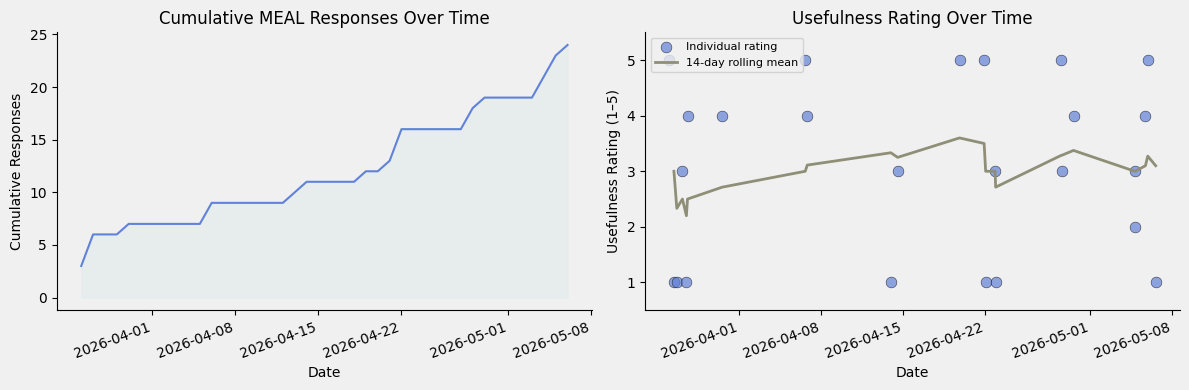

In [9]:
# Daily count of MEAL responses, then running total = cumulative reach of the survey
timeline = (
    meal.dropna(subset=['Timestamp'])
    .set_index('Timestamp')
    .resample('D')
    .size()
)
cumulative = timeline.cumsum()

# Sort by date so the rolling mean reads left-to-right chronologically
meal_sorted = meal.dropna(subset=['Timestamp', 'rating_num']).sort_values('Timestamp')
rolling_mean = (
    meal_sorted.set_index('Timestamp')['rating_num']
    .rolling('14D', min_periods=2)
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: cumulative responses collected over time
axes[0].fill_between(cumulative.index, cumulative.values, color=AGUA_LIGHT, alpha=0.6)
axes[0].plot(cumulative.index, cumulative.values, color=AGUA, linewidth=1.5)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Cumulative Responses')
axes[0].set_title('Cumulative MEAL Responses Over Time', fontsize=12)

# Right: individual ratings plus a 14-day rolling mean trend line
axes[1].scatter(meal_sorted['Timestamp'], meal_sorted['rating_num'],
                color=AGUA, alpha=0.7, s=60, edgecolors=NEGRO, linewidths=0.4,
                label='Individual rating')
axes[1].plot(rolling_mean.index, rolling_mean.values, color=MADERA, linewidth=2,
              label='14-day rolling mean')
axes[1].set_ylim(0.5, 5.5)
axes[1].set_yticks([1, 2, 3, 4, 5])
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Usefulness Rating (1–5)')
axes[1].set_title('Usefulness Rating Over Time', fontsize=12)
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_facecolor(CIELO)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()
